In [14]:
import os
import re
import json
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Annotated, List
import operator

In [15]:
load_dotenv()

True

In [16]:
model = ChatOllama(
    model = "gpt-oss:120b-cloud",
    base_url = "https://ollama.com",
    temperature=0.1,
    client_kwargs = {
        "headers":{
            "Authorization":f"Bearer {os.getenv('API_KEY')}"
        }
    }
)

In [17]:
def parse_feedback_response(text: str) -> dict:
    """Extract {feedback, score} from LLM response.
    Tries JSON first, then regex, then falls back to raw text."""
    # Try: find JSON block in response
    match = re.search(r'\{[^{}]*"feedback"[^{}]*"score"[^{}]*\}', text, re.DOTALL)
    if not match:
        match = re.search(r'\{[^{}]*"score"[^{}]*"feedback"[^{}]*\}', text, re.DOTALL)
    if match:
        try:
            data = json.loads(match.group())
            return {
                'feedback': str(data.get('feedback', text)),
                'score': max(0, min(10, int(data.get('score', 5))))
            }
        except (json.JSONDecodeError, ValueError):
            pass
    # Fallback: extract any number 0-10 near the word 'score'
    score_match = re.search(r'(?:score|Score)[^\d]*(\d+)(?:\.\d+)?\s*/\s*10', text)
    score = 5
    if score_match:
        score = max(0, min(10, int(score_match.group(1))))
    return {'feedback': text, 'score': score}

In [18]:
class EassyState(TypedDict):
    eassy:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_score:Annotated[List[int],operator.add]
    avg_score:float

In [19]:
def language_feedback(state:EassyState):
    eassy = state['eassy']
    prompt = f"""Evaluate the language quality of this essay as a UPSC exam checker.
Essay: {eassy}

Respond with ONLY a JSON object in this exact format (no other text):
{{"feedback": "your detailed feedback here", "score": <integer 0-10>}}"""
    raw = model.invoke(prompt).content
    result = parse_feedback_response(raw)
    return {'language_feedback': result['feedback'], 'individual_score': [result['score']]}

In [20]:
def analysis_feedback(state:EassyState):
    eassy = state['eassy']
    prompt = f"""Evaluate the depth of analysis in this essay as a UPSC exam checker.
Essay: {eassy}

Respond with ONLY a JSON object in this exact format (no other text):
{{"feedback": "your detailed feedback here", "score": <integer 0-10>}}"""
    raw = model.invoke(prompt).content
    result = parse_feedback_response(raw)
    return {'analysis_feedback': result['feedback'], 'individual_score': [result['score']]}

In [21]:
# FIX: renamed from clearity_feedback → clarity_feedback
def clarity_feedback(state:EassyState):
    eassy = state['eassy']
    prompt = f"""Evaluate the clarity of thoughts in this essay as a UPSC exam checker.
Essay: {eassy}

Respond with ONLY a JSON object in this exact format (no other text):
{{"feedback": "your detailed feedback here", "score": <integer 0-10>}}"""
    raw = model.invoke(prompt).content
    result = parse_feedback_response(raw)
    return {'clarity_feedback': result['feedback'], 'individual_score': [result['score']]}

In [22]:
def overall_feedback(state:EassyState):
    eassy = state['eassy']
    prompt = f"""Based on the following feedback, generate a summarized overall feedback for this essay.
Essay: {eassy}
Language quality: {state['language_feedback']}
Clarity of thoughts: {state['clarity_feedback']}
Depth of analysis: {state['analysis_feedback']}
Give 2 key points the writer must focus on to improve."""
    answer = model.invoke(prompt).content
    avg_score = sum(state['individual_score'])/len(state['individual_score']) if state['individual_score'] else 0
    return {'overall_feedback': answer, 'avg_score': avg_score}

In [23]:
graph = StateGraph(EassyState)

In [24]:
# FIX: node name 'clearity_feedback' → 'clarity_feedback'
graph.add_node('language_feedback', language_feedback)
graph.add_node('analysis_feedback', analysis_feedback)
graph.add_node('clarity_feedback', clarity_feedback)
graph.add_node('overall_feedback', overall_feedback)

graph.add_edge(START, 'language_feedback')
graph.add_edge(START, 'analysis_feedback')
graph.add_edge(START, 'clarity_feedback')

graph.add_edge('language_feedback', 'overall_feedback')
graph.add_edge('analysis_feedback', 'overall_feedback')
graph.add_edge('clarity_feedback', 'overall_feedback')

graph.add_edge('overall_feedback', END)
workflow = graph.compile()

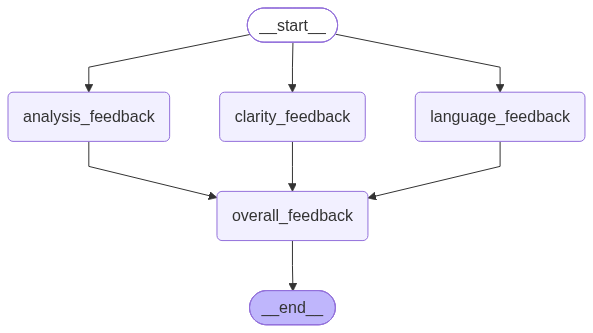

In [25]:
workflow

In [26]:
output = workflow.invoke({'eassy':"""Artificial intelligence has rapidly evolved from a visionary concept into the defining driving force of modern innovation, reshaping how human beings live, work, and solve complex global challenges. By processing vast amounts of data at unprecedented speeds, AI technologies are revolutionizing healthcare through precision diagnostics, optimizing global industries, and automating routine tasks to enhance productivity. However, this profound technological shift also brings significant ethical responsibilities, including data privacy concerns, algorithmic bias, and workforce displacement. Ultimately, navigating the future of artificial intelligence requires a balanced approach—harnessing its extraordinary power to boost human capability and societal progress while establishing robust safety guidelines to ensure its benefits are ethically and equitably distributed."""})

In [27]:
output

{'eassy': 'Artificial intelligence has rapidly evolved from a visionary concept into the defining driving force of modern innovation, reshaping how human beings live, work, and solve complex global challenges. By processing vast amounts of data at unprecedented speeds, AI technologies are revolutionizing healthcare through precision diagnostics, optimizing global industries, and automating routine tasks to enhance productivity. However, this profound technological shift also brings significant ethical responsibilities, including data privacy concerns, algorithmic bias, and workforce displacement. Ultimately, navigating the future of artificial intelligence requires a balanced approach—harnessing its extraordinary power to boost human capability and societal progress while establishing robust safety guidelines to ensure its benefits are ethically and equitably distributed.',
 'language_feedback': 'The essay demonstrates a strong command of language, with sophisticated vocabulary (e.g., 